In [1]:
from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
! pip list | grep vivarium

vivarium                  3.4.16
vivarium_build_utils      2.0.6
vivarium_cluster_tools    2.1.18
vivarium_dependencies     1.0.1
vivarium_gates_mncnh      0.1.dev260+g164fdd756.d20250912 /mnt/share/homes/alibow/vivarium_gates_mncnh
vivarium_public_health    4.3.8
vivarium_testing_utils    0.2.5


In [3]:
! pip freeze | grep vivarium

vivarium==3.4.16
vivarium_build_utils==2.0.6
vivarium_cluster_tools==2.1.18
vivarium_dependencies==1.0.1
-e git+https://github.com/ihmeuw/vivarium_gates_mncnh.git@164fdd7563817fb1e28b9c47caf0f9541e1b65f4#egg=vivarium_gates_mncnh
vivarium_public_health==4.3.8
vivarium_testing_utils==0.2.5


In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import InteractiveContext

In [5]:
from pathlib import Path

In [7]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

path = Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
custom_model_specification = build_model_specification(path)
del custom_model_specification.configuration.observers
artifact_dir = custom_model_specification.configuration.input_data.artifact_path
#custom_model_specification.configuration.input_data.artifact_path = artifact_dir.replace('ethiopia', 'pakistan')
custom_model_specification.configuration.input_data.input_draw_number = 60
custom_model_specification.configuration.population.population_size = 20_000 #* 10
custom_model_specification.configuration.intervention.scenario = 'ultrasound_vv'

In [8]:
from vivarium import Artifact 
art = Artifact(custom_model_specification.configuration.input_data.artifact_path)

In [9]:
draw_num = custom_model_specification.configuration.input_data.input_draw_number
draw = 'draw_' + str(draw_num)
draw

'draw_60'

In [10]:
# NOTE: We use only the first 100 draws from GBD, repeating them for later draws.
gbd_draw = 'draw_' + str(draw_num % 100)
gbd_draw

'draw_60'

In [11]:
sim = InteractiveContext(custom_model_specification)

2025-09-12 15:08:56.836 | INFO     | simulation_1-artifact_manager:79 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model16.2/ethiopia.hdf.
2025-09-12 15:08:56.837 | INFO     | simulation_1-artifact_manager:80 - Artifact base filter terms are ['draw == 60'].
2025-09-12 15:08:56.838 | INFO     | simulation_1-artifact_manager:81 - Artifact additional filter terms are None.
2025-09-12 15:09:17.068 | WARNING  | simulation_1-results_manager:446 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-09-12 15:09:17.070 | WARNING  | simulation_1-results_manager:446 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-09-12 15:09:17.333 | INFO     | simulation_1-results_manager:134 - The following stratifications are registered but not used by any observers: 
['sex']


In [12]:
get_event_name = sim._builder.time.simulation_event_name()
while get_event_name() != "delivery_facility":
    sim.step()
# now one more step to complete delivery facility event
sim.step()
pop = sim.get_population()
pop

,tracked,entrance_time,age,exit_time,alive,location,sex,first_trimester_anc,successful_lbw_identification,ultrasound_type,...,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_with_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_preterm_birth_with_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_without_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_preterm_birth_without_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk
0,True,2024-12-31,32.838854,NaT,alive,Ethiopia,Female,True,False,standard,...,1.688418,1.199788,1.199788,1.688418,1.199788,1.688418,1.199788,1.688418,1.688418,1.199788
1,True,2024-12-31,29.615904,NaT,alive,Ethiopia,Female,False,False,no_ultrasound,...,11.961044,21.175421,21.175421,11.961044,21.175421,11.961044,21.175421,11.961044,11.961044,21.175421
2,True,2024-12-31,31.716854,NaT,alive,Ethiopia,Female,True,False,standard,...,4.829565,3.291790,3.291790,4.829565,3.291790,4.829565,3.291790,4.829565,4.829565,3.291790
3,True,2024-12-31,31.383431,NaT,alive,Ethiopia,Female,False,False,AI_assisted,...,1.598626,1.213117,1.213117,1.598626,1.213117,1.598626,1.213117,1.598626,1.598626,1.213117
4,True,2024-12-31,21.400171,NaT,alive,Ethiopia,Female,False,False,AI_assisted,...,3.914854,2.651794,2.651794,3.914854,2.651794,3.914854,2.651794,3.914854,3.914854,2.651794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,True,2024-12-31,23.885567,NaT,alive,Ethiopia,Female,True,False,standard,...,2.151280,1.374011,1.374011,2.151280,1.374011,2.151280,1.374011,2.151280,2.151280,1.374011
19996,True,2024-12-31,21.476081,NaT,alive,Ethiopia,Female,True,False,AI_assisted,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
19997,True,2024-12-31,30.005203,NaT,alive,Ethiopia,Female,False,False,no_ultrasound,...,5.285324,7.501757,7.501757,5.285324,7.501757,5.285324,7.501757,5.285324,5.285324,7.501757
19998,True,2024-12-31,23.916808,NaT,alive,Ethiopia,Female,True,False,standard,...,1.824159,1.130333,1.130333,1.824159,1.130333,1.824159,1.130333,1.824159,1.824159,1.130333


In [13]:
cols = ['alive','first_trimester_anc','stated_gestational_age','ultrasound_type','anc_attendance',
        'successful_lbw_identification','later_pregnancy_anc','delivery_facility_type',
        'anc_state','pregnancy_outcome','gestational_age_exposure','birth_weight_exposure']
pop[cols]

,alive,first_trimester_anc,stated_gestational_age,ultrasound_type,anc_attendance,successful_lbw_identification,later_pregnancy_anc,delivery_facility_type,anc_state,pregnancy_outcome,gestational_age_exposure,birth_weight_exposure
0,alive,True,42.461982,standard,first_trimester_only,False,False,none,end,partial_term,40.010000,3014.748095
1,alive,False,33.836543,no_ultrasound,none,False,False,home,end,live_birth,33.325864,2178.729992
2,alive,True,40.896606,standard,first_trimester_and_later_pregnancy,False,True,CEmONC,end,live_birth,38.334218,2427.084365
3,alive,False,38.330869,AI_assisted,later_pregnancy_only,False,True,home,end,live_birth,37.265309,3478.066076
4,alive,False,39.220853,AI_assisted,later_pregnancy_only,False,True,home,end,live_birth,39.303239,2505.672243
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,alive,True,39.675573,standard,first_trimester_only,False,False,none,end,partial_term,39.845380,2930.581288
19996,alive,True,39.444214,AI_assisted,first_trimester_only,False,False,none,end,partial_term,39.273046,3991.744741
19997,alive,False,33.070125,no_ultrasound,none,False,False,CEmONC,end,live_birth,34.704896,2783.352963
19998,alive,True,37.530460,standard,first_trimester_and_later_pregnancy,False,True,home,end,live_birth,38.452581,3096.745741


In [14]:
df = pd.concat([pop[cols],
                sim.get_value('antenatal_care.correlated_propensity')(pop.index),
                sim.get_value('risk_factor.low_birth_weight_and_short_gestation.correlated_propensity')(pop.index),
                sim.get_value('delivery_facility.correlated_propensity')(pop.index)], axis=1)
df['anc1'] = df.anc_attendance != 'none'
df['ifd'] = df.delivery_facility_type.isin(['BEmONC','CEmONC'])
df['preterm'] = df.gestational_age_exposure < 37
df['believed_preterm'] = df.stated_gestational_age < 37
# let's get rid of partial term pregnancies
df = df.loc[df.pregnancy_outcome != 'partial_term']
df

,alive,first_trimester_anc,stated_gestational_age,ultrasound_type,anc_attendance,successful_lbw_identification,later_pregnancy_anc,delivery_facility_type,anc_state,pregnancy_outcome,gestational_age_exposure,birth_weight_exposure,antenatal_care.correlated_propensity,risk_factor.low_birth_weight_and_short_gestation.correlated_propensity,delivery_facility.correlated_propensity,anc1,ifd,preterm,believed_preterm
1,alive,False,33.836543,no_ultrasound,none,False,False,home,end,live_birth,33.325864,2178.729992,0.013338,0.049417,0.003964,False,False,True,True
2,alive,True,40.896606,standard,first_trimester_and_later_pregnancy,False,True,CEmONC,end,live_birth,38.334218,2427.084365,0.748349,0.177470,0.762619,True,True,False,False
3,alive,False,38.330869,AI_assisted,later_pregnancy_only,False,True,home,end,live_birth,37.265309,3478.066076,0.542904,0.534239,0.389735,True,False,False,False
4,alive,False,39.220853,AI_assisted,later_pregnancy_only,False,True,home,end,live_birth,39.303239,2505.672243,0.324762,0.358559,0.145581,True,False,False,False
5,alive,False,42.260488,no_ultrasound,none,False,False,home,end,live_birth,39.678983,2749.674317,0.137784,0.369074,0.490203,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19992,alive,True,40.507073,standard,first_trimester_and_later_pregnancy,False,True,BEmONC,end,live_birth,39.606116,3258.932880,0.659181,0.673309,0.990010,True,True,False,False
19994,alive,False,39.684552,standard,later_pregnancy_only,False,True,home,end,live_birth,39.021326,2504.043211,0.404988,0.403117,0.464967,True,False,False,False
19997,alive,False,33.070125,no_ultrasound,none,False,False,CEmONC,end,live_birth,34.704896,2783.352963,0.048991,0.148168,0.489586,False,True,True,True
19998,alive,True,37.530460,standard,first_trimester_and_later_pregnancy,False,True,home,end,live_birth,38.452581,3096.745741,0.711594,0.721683,0.422117,True,False,False,False


In [15]:
df.groupby('anc1')['antenatal_care.correlated_propensity'].mean()

anc1
False    0.130059
True     0.628246
Name: antenatal_care.correlated_propensity, dtype: float64

In [16]:
df.groupby('ifd')['delivery_facility.correlated_propensity'].mean()

ifd
False    0.258395
True     0.748379
Name: delivery_facility.correlated_propensity, dtype: float64

In [17]:
df.groupby('preterm')['risk_factor.low_birth_weight_and_short_gestation.correlated_propensity'].mean()

preterm
False    0.578562
True     0.085218
Name: risk_factor.low_birth_weight_and_short_gestation.correlated_propensity, dtype: float64

In [18]:
# all propensities are ordered as expected

In [19]:
df[['antenatal_care.correlated_propensity',
    'risk_factor.low_birth_weight_and_short_gestation.correlated_propensity',
    'delivery_facility.correlated_propensity']].corr()

# according to docs here: https://vivarium-research.readthedocs.io/en/latest/models/other_models/facility_choice/index.html#id6
# target is 0.2 for everything except between ANC/IFD it is 0.63 for Ethiopia
# so we're looking good here

,antenatal_care.correlated_propensity,risk_factor.low_birth_weight_and_short_gestation.correlated_propensity,delivery_facility.correlated_propensity
antenatal_care.correlated_propensity,1.000000,0.190941,0.611558
risk_factor.low_birth_weight_and_short_gestation.correlated_propensity,0.190941,1.000000,0.186440
delivery_facility.correlated_propensity,0.611558,0.186440,1.000000


In [20]:
draw

'draw_60'

In [21]:
anc1 = art.load('covariate.antenatal_care_1_visit_coverage_proportion.estimate')[draw].values[0]
ifd = art.load('covariate.in_facility_delivery_proportion.estimate')#[draw].values[0]
ifd

0.492568484342463

Text(0.5, 1.0, 'ANC attendance and propensities')

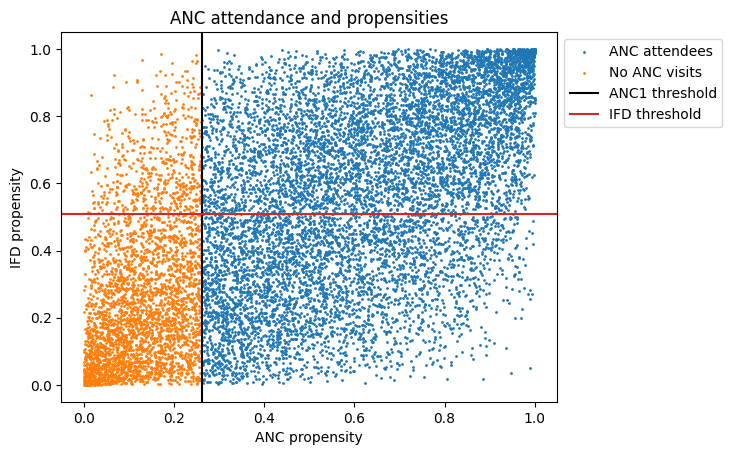

In [22]:
import matplotlib.pyplot as plt

for val in [True, False]:
    p = df.loc[df.anc1==val]
    if val:
        color='tab:blue'
        label='ANC attendees'
    else:
        color='tab:orange'
        label='No ANC visits'
    plt.scatter(p['antenatal_care.correlated_propensity'], p['delivery_facility.correlated_propensity'], s=1, 
                color=color, label=label)
plt.axvline(1-anc1, label='ANC1 threshold', color='black')
plt.axhline(1-ifd, label='IFD threshold', color='tab:red')
plt.xlabel('ANC propensity')
plt.ylabel('IFD propensity')
plt.legend(bbox_to_anchor=[1,1])
plt.title('ANC attendance and propensities')

In [23]:
# now let's do a quick check on believed vs. true preterm and ultrasound coverage

In [24]:
targets = pd.read_csv('../facility_choice/facility_choice_validation_targets.csv')
confusion_matrix = targets.loc[targets.probability_of.isin(['believed_term_given_term',
                                         'believed_preterm_given_term',
                                         'believed_preterm_given_preterm',
                                         'believed_term_given_preterm'])][['probability_of','Ethiopia']].reset_index().drop(columns='index')
confusion_matrix['preterm'] = [True, True, False, False]
confusion_matrix['believed_preterm'] = [True, False, True, False]
confusion_matrix

,probability_of,Ethiopia,preterm,believed_preterm
0,believed_preterm_given_preterm,0.886309,True,True
1,believed_term_given_preterm,0.113691,True,False
2,believed_preterm_given_term,0.141593,False,True
3,believed_term_given_term,0.858407,False,False


In [25]:
(df.groupby(['preterm']).believed_preterm.value_counts(normalize=True).reset_index()
           .merge(confusion_matrix, on=['preterm','believed_preterm'], how='outer'))
# yay, looking way better


,preterm,believed_preterm,proportion,probability_of,Ethiopia
0,False,False,0.885308,believed_term_given_term,0.858407
1,False,True,0.114692,believed_preterm_given_term,0.141593
2,True,False,0.093820,believed_term_given_preterm,0.113691
3,True,True,0.906180,believed_preterm_given_preterm,0.886309


In [26]:
trivariate = targets.loc[targets.probability_of.isin(['believed_preterm_given_preterm_and_no_ultrasound',
       'believed_term_given_preterm_and_no_ultrasound',
       'believed_preterm_given_preterm_and_standard_ultrasound',
       'believed_term_given_preterm_and_standard_ultrasound',
       'believed_preterm_given_term_and_no_ultrasound',
       'believed_term_given_term_and_no_ultrasound',
       'believed_preterm_given_term_and_standard_ultrasound',
       'believed_term_given_term_and_standard_ultrasound'])][['probability_of','Ethiopia']].reset_index().drop(columns='index')
trivariate['believed_preterm'] = np.where(trivariate.probability_of.str.contains('believed_preterm'), True, False)
trivariate['preterm'] = np.where(trivariate.probability_of.str.contains('given_preterm'), True, False)
trivariate['ultrasound_type'] = np.where(trivariate.probability_of.str.contains('standard_ultrasound'), 'standard', 'no_ultrasound')
trivariate


,probability_of,Ethiopia,believed_preterm,preterm,ultrasound_type
0,believed_preterm_given_preterm_and_no_ultrasound,0.873752,True,True,no_ultrasound
1,believed_term_given_preterm_and_no_ultrasound,0.126248,False,True,no_ultrasound
2,believed_preterm_given_preterm_and_standard_ul...,0.905099,True,True,standard
3,believed_term_given_preterm_and_standard_ultra...,0.094901,False,True,standard
4,believed_preterm_given_term_and_no_ultrasound,0.168487,True,False,no_ultrasound
5,believed_term_given_term_and_no_ultrasound,0.831513,False,False,no_ultrasound
6,believed_preterm_given_term_and_standard_ultra...,0.111403,True,False,standard
7,believed_term_given_term_and_standard_ultrasound,0.888597,False,False,standard


In [27]:
(df.groupby(['ultrasound_type','preterm']).believed_preterm.value_counts(normalize=True).reset_index()
 .merge(trivariate, on=['believed_preterm','preterm','ultrasound_type'], how='outer'))

# great!

,ultrasound_type,preterm,believed_preterm,proportion,probability_of,Ethiopia
0,AI_assisted,False,False,0.916216,NaN,NaN
1,no_ultrasound,False,False,0.831865,believed_term_given_term_and_no_ultrasound,0.831513
2,standard,False,False,0.888671,believed_term_given_term_and_standard_ultrasound,0.888597
3,AI_assisted,True,False,0.070637,NaN,NaN
4,no_ultrasound,True,False,0.103811,believed_term_given_preterm_and_no_ultrasound,0.126248
5,standard,True,False,0.106267,believed_term_given_preterm_and_standard_ultra...,0.094901
6,AI_assisted,False,True,0.083784,NaN,NaN
7,no_ultrasound,False,True,0.168135,believed_preterm_given_term_and_no_ultrasound,0.168487
8,standard,False,True,0.111329,believed_preterm_given_term_and_standard_ultra...,0.111403
9,AI_assisted,True,True,0.929363,NaN,NaN


In [ ]:
# so let's see if we can confirm that the ultrasound detection of preterm is going correctly

In [29]:
df['ga_error'] = (df.stated_gestational_age - df.gestational_age_exposure) * 7
df[['gestational_age_exposure','stated_gestational_age','ga_error','ultrasound_type']]

,gestational_age_exposure,stated_gestational_age,ga_error,ultrasound_type
1,33.325864,33.836543,3.574757,no_ultrasound
2,38.334218,40.896606,17.936713,standard
3,37.265309,38.330869,7.458920,AI_assisted
4,39.303239,39.220853,-0.576700,AI_assisted
5,39.678983,42.260488,18.070531,no_ultrasound
...,...,...,...,...
19992,39.606116,40.507073,6.306700,standard
19994,39.021326,39.684552,4.642584,standard
19997,34.704896,33.070125,-11.443396,no_ultrasound
19998,38.452581,37.530460,-6.454850,standard


In [ ]:
df.groupby('ultrasound_type').ga_error.describe()

# docs are here: https://vivarium-research.readthedocs.io/en/latest/models/concept_models/vivarium_mncnh_portfolio/ai_ultrasound_module/module_document.html#calculation-of-estimated-gestational-age

# so confirmed that AI assisted US has the expected error as well, which we did not confirm
# previously in the baseline scenario

,count,mean,std,min,25%,50%,75%,max
ultrasound_type,,,,,,,,
AI_assisted,4792.0,0.097856,4.985892,-18.895509,-3.279884,0.164284,3.494734,16.782342
no_ultrasound,3372.0,-0.086131,10.000611,-34.968649,-6.432151,0.104766,6.549715,30.554786
standard,4821.0,-0.013206,6.777406,-22.946614,-4.549397,0.034643,4.669602,27.798977


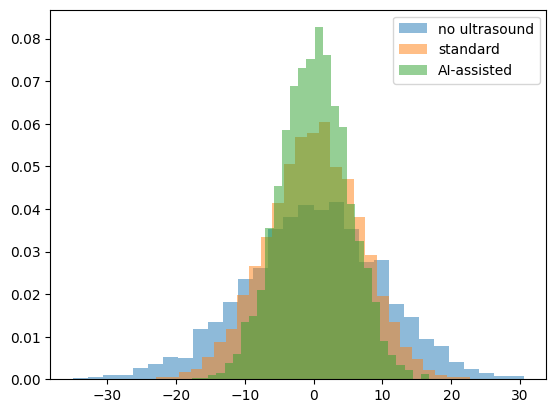

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df.loc[df.ultrasound_type=='no_ultrasound'].ga_error, bins=30, alpha=0.5, label='no ultrasound', density=True)
plt.hist(df.loc[df.ultrasound_type=='standard'].ga_error, bins=30, alpha=0.5, label='standard', density=True)
plt.hist(df.loc[df.ultrasound_type=='AI_assisted'].ga_error, bins=30, alpha=0.5, label='AI-assisted', density=True)
plt.legend()